In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('E:\Data_Urang\Informatics_Research_Centre\Salary_Data.csv')

In [4]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [5]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [6]:
df.tail()

,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


In [8]:
x = df.iloc[:, :-1] #masukkan semua column, kecuali column salary
y = df.iloc[:, 1] #masukkan semua column, kecuali column YearsExperience

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/3, random_state=0)
#Maksudnya disini data yang ada kita split jadi beberapa bagian. Ada data train dan data test, dan disini untuk Data test nya digunakan sebanyak 30% dari banyaknya data

# MODELLING MACHINE LEARNING

In [10]:
#Modelling Machine Learning
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)
print(regressor.coef_)
print(regressor.intercept_)

[9345.94244312]
26816.19224403119


In [11]:
y_pred = regressor.predict(x_test)

##### Data Training

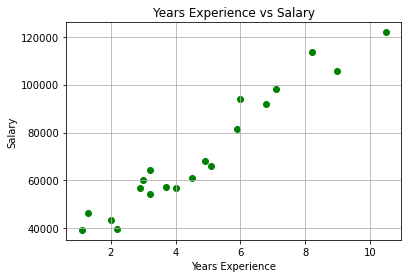

In [12]:
import matplotlib.pyplot as plt
plt.scatter(x_train, y_train, color="green")
plt.title("Years Experience vs Salary")
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.grid()
plt.show()

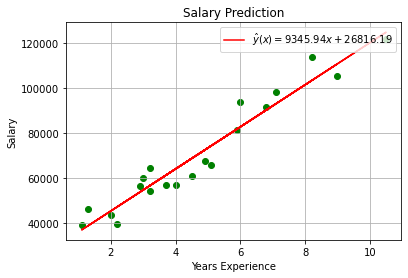

In [13]:
import matplotlib.pyplot as plt
plt.scatter(x_train, y_train, color="green")
plt.plot(x_train, regressor.predict(x_train), color="red")
plt.title("Salary Prediction")
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.legend(('$\hat{y}(x)=9345.94x+26816.19$',),loc='upper right')
plt.grid()
plt.show()

In [14]:
from sklearn.metrics import r2_score
r2 =r2_score (x_train,y_train)
print ('Nilai R2 adalah',r2)

Nilai R2 adalah -880628584.5041302


In [15]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats

def ANOVATAB(y,yhat,n,m):
    dfn=n
    dfd=m-n-1
    ybar=np.average(y)

    SSR=sum((yhat-ybar)**2)
    SSE=sum((y-yhat)**2)
    print (SSE)
    print (dfd)
    SST=sum((y-ybar)**2)
    MSR=SSR/dfn
    MSE=SSE/dfd

    Fs=MSR/MSE
    ks =1-scipy.stats.f.cdf(Fs,dfn,dfd)
    data_table={
        'SS' : [SSR,SSE,SST],
        'df' : [dfn,dfd,m-1],
        'MS' : [MSR,MSE,'-'],
        'Fs' : [Fs,'-','-'],
        'pval' : [ks,'-','-']
    }
    return pd.DataFrame(data_table)

In [16]:
n=1
m=len(y_pred)
print('Tabel Anovanya')
result=ANOVATAB(y_test,y_pred,n,m)
result

Tabel Anovanya
210260373.29511297
8


,SS,df,MS,Fs,pval
0,7.449347e+09,1,7449346936.223261,283.433224,0.0
1,2.102604e+08,8,26282546.661889,-,-
2,8.382064e+09,9,-,-,-


Kesimpulan karena karena Fhit > F-sign maka regresi ini signifikan, tolak H₀ : Regresi tidak signifikan, H1 : Regresi signifikan bahwa secara populasi, terdapat hubungan linier antara stopdist dengan speed Keputusan : Tolak H₀ karena Fhit > F-sign Kesimpulan : Regresi signifikan

##### Data Testing

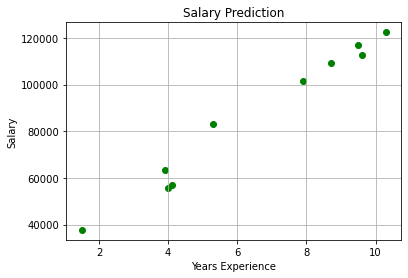

In [17]:
plt.scatter(x_test, y_test, color="green")
plt.title("Salary Prediction")
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.grid()
plt.show()

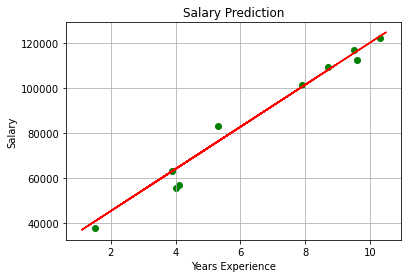

In [18]:
plt.scatter(x_test, y_test, color="green")
plt.plot(x_train, regressor.predict(x_train), color="red")
plt.title("Salary Prediction")
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.grid()
plt.show()

# MAKE NEW PREDICTION

In [19]:
salary_pred = regressor.predict([[1000]])
print("The salary for that amount of years experience is: ", salary_pred)

The salary for that amount of years experience is:  [9372758.6353664]
